# Estimación del Valor de Departamentos en Mérida mediante Modelos de Aprendizaje Automático

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from IPython.display import display

## 1. Carga, limpieza de la información y análisis exploratorio de datos

##### Debido a la extración de la información por medio de diferentes fuentes, se necesita hacer una limpieza a los datos que se han añadido a la base y que no están configurados con su tipo correspondiente, en este caso los datos numéricos

In [59]:
departamentos = pd.read_excel("Base Casas.xlsx")
departamentos.head(5)

,Nombre del desarrollo,Nombre modelo,Auxiliar Princ Comp,Tipo,Activo,Unidades Totales (Modelo),Unidades Vendidas (Modelo),Unidades disponibles (Modelo),Número de Recámaras,Sala,...,Precio M2,Unidades Totales,Privada,Número de amenidades,Número de Pisos Habitables,Cholul,Temozón Norte,Dzityá,Santa Gertrudis Copó,Paseos del Norte
0,Distrito Lahun,B1,Distrito Lahun-B1,Departamento,1,56,6,50,2,1,...,"37,452.66",155,1,8,6,1,0,0,0,0
1,Distrito Lahun,B2,Distrito Lahun-B2,Departamento,1,60,8,52,2,1,...,"35,244.19",155,1,8,6,1,0,0,0,0
2,Distrito Lahun,A2,Distrito Lahun-A2,Departamento,1,26,5,21,3,1,...,"29,691.80",155,1,8,6,1,0,0,0,0
3,Distrito Lahun,A1,Distrito Lahun-A1,Departamento,1,13,7,6,3,1,...,"33,321.25",155,1,8,6,1,0,0,0,0
4,Baura,A,Baura-A,Departamento,0,10,10,0,1,1,...,ND,38,1,5,4,0,0,0,1,0


In [60]:
cols_numericas = [
    'Precio','M2 Total','Número de Recámaras','Número de baños','Espacios de Estacionamiento','Número de amenidades'
    ] #Columnas con valores numéricos

In [61]:
for col in cols_numericas:
    departamentos[col] = pd.to_numeric(departamentos[col],errors='coerce') 
#Evitar que los valores numéricos esten en otro tipo de dato (Texto)

In [62]:
departamentos = departamentos.dropna(subset=cols_numericas) 
#Eliminar los registros que tengan valores nulos en las columnas númericas

In [63]:
departamentos.head(5)

,Nombre del desarrollo,Nombre modelo,Auxiliar Princ Comp,Tipo,Activo,Unidades Totales (Modelo),Unidades Vendidas (Modelo),Unidades disponibles (Modelo),Número de Recámaras,Sala,...,Precio M2,Unidades Totales,Privada,Número de amenidades,Número de Pisos Habitables,Cholul,Temozón Norte,Dzityá,Santa Gertrudis Copó,Paseos del Norte
0,Distrito Lahun,B1,Distrito Lahun-B1,Departamento,1,56,6,50,2.00,1,...,"37,452.66",155,1,8,6,1,0,0,0,0
1,Distrito Lahun,B2,Distrito Lahun-B2,Departamento,1,60,8,52,2.00,1,...,"35,244.19",155,1,8,6,1,0,0,0,0
2,Distrito Lahun,A2,Distrito Lahun-A2,Departamento,1,26,5,21,3.00,1,...,"29,691.80",155,1,8,6,1,0,0,0,0
3,Distrito Lahun,A1,Distrito Lahun-A1,Departamento,1,13,7,6,3.00,1,...,"33,321.25",155,1,8,6,1,0,0,0,0
5,Baura,B,Baura-B,Departamento,1,10,5,5,2.00,1,...,"33,701.30",38,1,5,4,0,0,0,1,0


In [64]:
Tipos = ['Departamento', 'Pentgarden', 'Penthouse', 'loft']
pd.options.display.float_format = '{:,.2f}'.format

for tipo in Tipos:
    print(tipo)
    df_filtrado = departamentos[departamentos["Tipo"]==tipo]
    df_filtrado = df_filtrado[[
        "M2 Total","Número de Recámaras","Número de baños",
        "Espacios de Estacionamiento","Número de amenidades", "Precio"
        ]]
    display(df_filtrado.describe())

Departamento


,M2 Total,Número de Recámaras,Número de baños,Espacios de Estacionamiento,Número de amenidades,Precio
count,210.00,210.00,210.00,210.00,210.00,210.00
mean,87.48,1.81,1.68,1.40,9.79,"3,553,680.78"
std,44.02,0.77,0.60,0.59,5.60,"1,955,424.24"
min,40.60,1.00,1.00,0.00,0.00,"1,345,000.00"
25%,62.70,1.00,1.00,1.00,7.00,"2,200,000.00"
50%,80.00,2.00,2.00,1.00,8.00,"3,166,318.00"
75%,100.70,2.00,2.00,2.00,11.00,"4,190,000.00"
max,282.41,3.00,3.00,3.00,23.00,"11,395,000.00"


Pentgarden


,M2 Total,Número de Recámaras,Número de baños,Espacios de Estacionamiento,Número de amenidades,Precio
count,11.00,11.00,11.00,11.00,11.00,11.00
mean,96.00,1.45,1.45,1.27,8.91,"3,309,189.66"
std,60.40,0.69,0.69,0.47,6.12,"2,577,079.64"
min,47.50,1.00,1.00,1.00,0.00,"1,599,000.00"
25%,56.35,1.00,1.00,1.00,4.50,"1,988,500.00"
50%,73.00,1.00,1.00,1.00,7.00,"2,399,000.00"
75%,105.50,2.00,2.00,1.50,15.00,"3,469,000.00"
max,248.00,3.00,3.00,2.00,17.00,"10,595,000.00"


Penthouse


,M2 Total,Número de Recámaras,Número de baños,Espacios de Estacionamiento,Número de amenidades,Precio
count,12.00,12.00,12.00,12.00,12.00,12.00
mean,145.62,2.08,2.00,1.67,9.92,"5,526,475.00"
std,39.12,0.79,0.74,0.49,4.54,"2,234,683.27"
min,95.60,1.00,1.00,1.00,5.00,"2,774,000.00"
25%,117.51,1.75,1.75,1.00,6.75,"3,925,175.00"
50%,137.75,2.00,2.00,2.00,8.00,"5,650,000.00"
75%,168.12,3.00,2.25,2.00,12.50,"6,827,500.00"
max,213.01,3.00,3.00,2.00,17.00,"9,850,000.00"


loft


,M2 Total,Número de Recámaras,Número de baños,Espacios de Estacionamiento,Número de amenidades,Precio
count,2.00,2.00,2.00,2.00,2.00,2.00
mean,44.80,1.00,1.00,1.00,10.00,"1,966,250.00"
std,12.45,0.00,0.00,0.00,1.41,"694,732.41"
min,36.00,1.00,1.00,1.00,9.00,"1,475,000.00"
25%,40.40,1.00,1.00,1.00,9.50,"1,720,625.00"
50%,44.80,1.00,1.00,1.00,10.00,"1,966,250.00"
75%,49.20,1.00,1.00,1.00,10.50,"2,211,875.00"
max,53.60,1.00,1.00,1.00,11.00,"2,457,500.00"


## 2. Definición de las variables del modelo

##### Teniendo en cuenta que las unidades se encuentran en desarrollos inmobiliarios, se tomá en cuenta las siguientes carácteristicas como las principales para la determinación de la varibailidad de su precio. 

In [65]:
departamentos_filt = departamentos[departamentos["Tipo"]=="Departamento"]

#Características principales del modelo
caracteristicas = [
    'M2 Total','Número de Recámaras','Número de baños','Espacios de Estacionamiento','Número de amenidades',
    'Cholul','Temozón Norte','Dzityá','Santa Gertrudis Copó','Paseos del Norte'
] 

#Variables
X = departamentos_filt[caracteristicas]
y = departamentos_filt["Precio"]
y_log = np.log(departamentos_filt['Precio'])

In [66]:
X

,M2 Total,Número de Recámaras,Número de baños,Espacios de Estacionamiento,Número de amenidades,Cholul,Temozón Norte,Dzityá,Santa Gertrudis Copó,Paseos del Norte
0,62.90,2.00,2.00,1.00,8,1,0,0,0,0
1,62.70,2.00,2.00,1.00,8,1,0,0,0,0
2,100.80,3.00,2.00,2.00,8,1,0,0,0,0
3,96.80,3.00,2.00,2.00,8,1,0,0,0,0
5,77.00,2.00,2.00,2.00,5,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...
269,60.00,2.00,2.00,1.00,9,1,0,0,0,0
270,45.00,1.00,1.00,1.00,9,1,0,0,0,0
272,184.06,1.00,2.00,2.00,12,0,0,0,0,1
277,209.78,2.00,2.00,2.00,16,0,0,0,0,1


# 3. Separación entrenamiento y prueba

##### Hacemos la separación de datos para que el modelo pueda tener datos para entrenar y otros datos para hacer las pruebas con el modelo

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y_log,test_size=0.2,random_state=42) # 80% Entrenamiento y 20% Prueba para el modelo 

# 4. Entreno del modelo de regresión lineal

##### Con la regresión lineal buscamos reducir el error cuadratico para encontrar las betas que mejor se ajustan al modelo 

In [68]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

pred_log = modelo.predict(X_test)   

# 5. Evaluación de métricas

##### Para evaluar el desempeño del modelo se emplearon distintas métricas de error, entre ellas el Error Absoluto Medio (MAE), la Raíz del Error Cuadrático Medio (RMSE), el coeficiente de determinación ($R^2$) y el Error Porcentual promedio. Estas métricas permiten cuantificar qué tan cercana es la estimación generada por el modelo respecto al valor real del departamento, proporcionando una medida tanto en unidades monetarias como en términos relativos.

In [76]:
y_test_original = np.exp(y_test)
pred_original = np.exp(pred_log)

mae = mean_absolute_error(y_test_original, pred_original)
rmse = np.sqrt(mean_squared_error(y_test_original, pred_original))
r2 = r2_score(y_test_original, pred_original)
error_pct = np.mean(np.abs((y_test_original - pred_original) / y_test)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("Error porcentual promedio:", error_pct)

MAE: 534128.5330569262
RMSE: 942138.140450169
R2: 0.8292256992780662
Error porcentual promedio: 3447276.37223068


# 6. Interpretación de coeficientes

##### Si dejaramos todos los coeficientes constantes ¿Cómo sería la variación de x coeficiente? Bueno, eso lo responde esta sección, que nos dice como afecto la beta en el modelo al haber un cambio sobre x variable

In [79]:
coeficientes = pd.DataFrame({'Variable': caracteristicas,'Coeficiente': modelo.coef_}).sort_values(by='Coeficiente', ascending=False)

print(coeficientes)

                      Variable  Coeficiente
8         Santa Gertrudis Copó         0.15
9             Paseos del Norte         0.14
1          Número de Recámaras         0.13
3  Espacios de Estacionamiento         0.05
4         Número de amenidades         0.03
0                     M2 Total         0.01
6                Temozón Norte        -0.02
5                       Cholul        -0.07
2              Número de baños        -0.07
7                       Dzityá        -0.20


# 7. Comparación Real vs Estimada (Regresión Lineal)

##### La distribución de errores obtenida nos debería de dar valores cercanos a 0, mientras más alejados a 0 son valores que nos indican que hay outliers en el modelo.

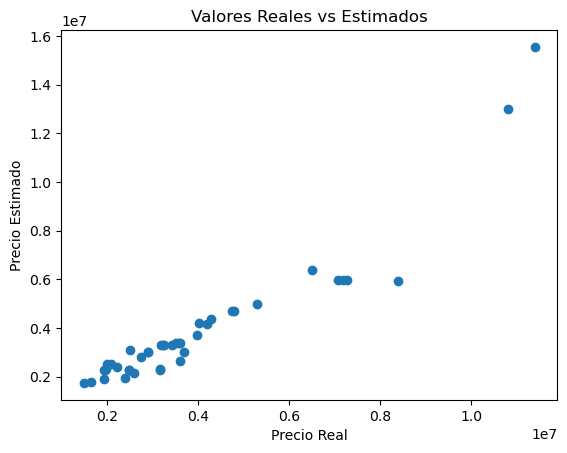

In [80]:
plt.figure()
plt.scatter(y_test_original, pred_original)
plt.xlabel("Precio Real")
plt.ylabel("Precio Estimado")
plt.title("Valores Reales vs Estimados")
plt.savefig("real_vs_predicho.png", dpi=300)
plt.show()

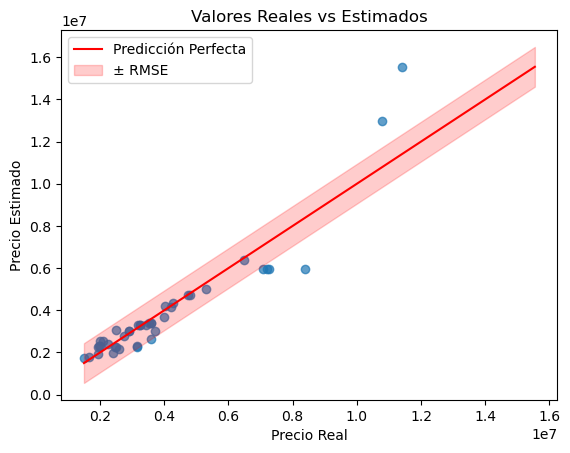

In [82]:
plt.figure()

# Scatter
plt.scatter(y_test_original, pred_original, alpha=0.7)

# Línea ideal y = x
min_val = min(y_test_original.min(), pred_original.min())
max_val = max(y_test_original.max(), pred_original.max())

x_vals = np.linspace(min_val, max_val, 100)

plt.plot(x_vals, x_vals, color='red', label='Predicción Perfecta')

# Banda de ± RMSE
plt.fill_between(
    x_vals,
    x_vals - rmse,
    x_vals + rmse,
    color='red',
    alpha=0.2,
    label='± RMSE'
)

plt.xlabel("Precio Real")
plt.ylabel("Precio Estimado")
plt.title("Valores Reales vs Estimados")
plt.legend()

plt.savefig("real_vs_predicho_con_banda.png", dpi=300)
plt.show()

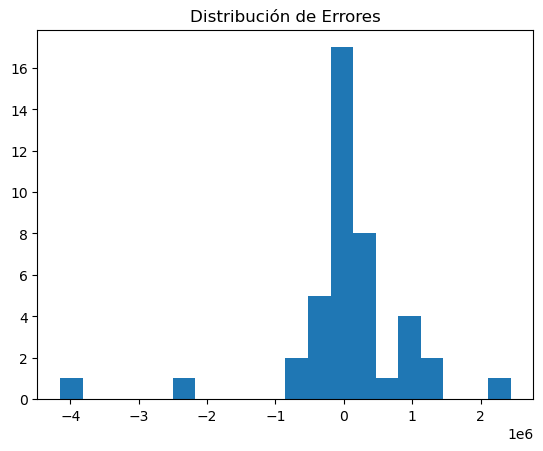

In [84]:
errores = y_test_original - pred_original

plt.figure()
plt.hist(errores, bins=20)
plt.title("Distribución de Errores")
plt.savefig("histograma_errores.png", dpi=300)
plt.show()

# 8. Modelo Ranodom Forest

##### Para hacer contraste al modelo de regresión lineal y tener una visión más completa sobre los modelos de ML, se opta por realizar un pequeño modelo de Random Forest para ver su eficacia. En el siguiente modelo se tomó como parámetro 200 árboles de desición (n_estimators), una profundidad de 6 (max_depth) esto para controlar el sobre ajuste.

In [94]:
rf = RandomForestRegressor(n_estimators=200,max_depth=6,random_state=42)

rf.fit(X_train, y_train)
pred_log_rf = rf.predict(X_test)

y_test_original = np.exp(y_test)
pred_rf_original = np.exp(pred_log_rf)

print("MAE RF:", mean_absolute_error(y_test_original, pred_rf_original))
print("R2 RF:", r2_score(y_test_original, pred_rf_original))
print("RMSE RF:",np.sqrt(mean_squared_error(y_test_original, pred_rf_original)))

rmse_rf = np.sqrt(mean_squared_error(y_test_original, pred_rf_original))

MAE RF: 300754.95013984654
R2 RF: 0.9429126308047359
RMSE RF: 544720.0268155455


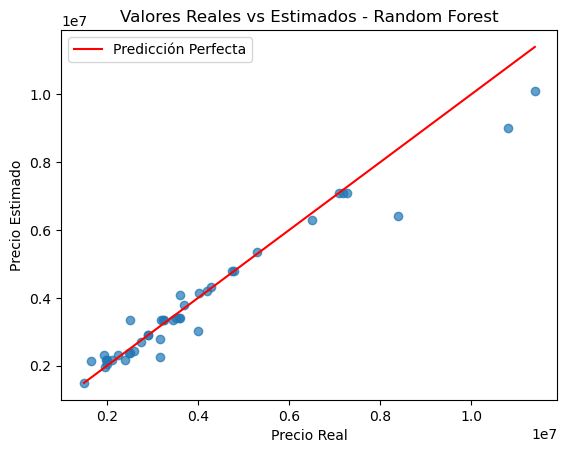

In [100]:
plt.figure()

plt.scatter(y_test_original, pred_rf_original, alpha=0.7)

# Línea perfecta y = x
min_val = min(y_test_original.min(), pred_rf_original.min())
max_val = max(y_test_original.max(), pred_rf_original.max())

plt.plot([min_val, max_val], [min_val, max_val], color='red', label='Predicción Perfecta')

plt.xlabel("Precio Real")
plt.ylabel("Precio Estimado")
plt.title("Valores Reales vs Estimados - Random Forest")
plt.legend()

plt.savefig("real_vs_predicho_rf.png", dpi=300)
plt.show()

# 9. Evaluación de métricas del modelo Random Forest y gráficas

                      Variable  Importancia
0                     M2 Total         0.57
4         Número de amenidades         0.37
3  Espacios de Estacionamiento         0.02
9             Paseos del Norte         0.01
1          Número de Recámaras         0.01
5                       Cholul         0.01
2              Número de baños         0.01
8         Santa Gertrudis Copó         0.01
7                       Dzityá         0.00
6                Temozón Norte         0.00


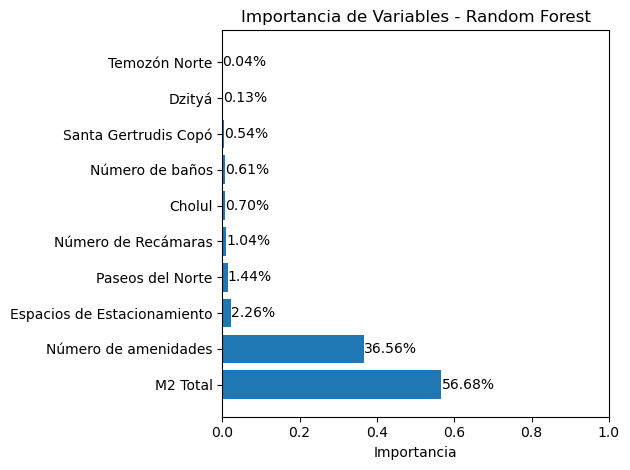

In [46]:
importancias = pd.DataFrame({'Variable': caracteristicas,'Importancia': rf.feature_importances_}).sort_values(by='Importancia', ascending=False)

print(importancias)

plt.figure()
plt.barh(importancias['Variable'], importancias['Importancia'])
plt.title("Importancia de Variables - Random Forest")
for i, v in enumerate(importancias['Importancia']):
    plt.text(v, i, f"{v*100:.2f}%", va='center')

plt.xlim(0,1)
plt.xlabel("Importancia")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()

##### El análisis de residuos no muestra patrones sistemáticos evidentes, aunque se observa mayor dispersión en el segmento de mayor valor, lo cual sugiere heterocedasticidad leve propia del mercado inmobiliario.

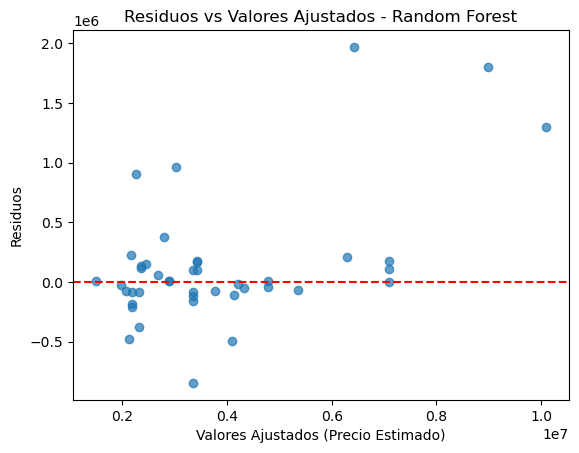

In [99]:
residuos_rf = y_test_original - pred_rf_original

plt.figure()

plt.scatter(pred_rf_original, residuos_rf, alpha=0.7)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Valores Ajustados (Precio Estimado)")
plt.ylabel("Residuos")
plt.title("Residuos vs Valores Ajustados - Random Forest")

plt.savefig("residuos_vs_ajustados_rf.png", dpi=300)
plt.show()